In [2]:
%matplotlib inline

In [3]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import squidpy as sq
from PIL import Image

/home/mwc/miniconda3/envs/st/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/mwc/miniconda3/envs/st/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


AnnData object with n_obs × n_vars = 744 × 33538
    obs: 'r'
    uns: 'spatial'
    obsm: 'spatial'
[[1313.9033102  1180.90117688]
 [1258.60901012 1391.95246628]
 [1104.14146264 1468.56048148]
 [1060.49006388  892.90054944]
 [1192.39237916 1468.636331  ]]
                                                r
GSE144239_GSM4565823_AAACAAGTATCTCCCA-1  7.167827
GSE144239_GSM4565823_AAACATTTCCCGGATT-1  7.167827
GSE144239_GSM4565823_AAACCTAAGCAGCCGG-1  7.167827
GSE144239_GSM4565823_AAACGAGACGGTTGAT-1  7.167827
GSE144239_GSM4565823_AAACGGGCGTACGGGT-1  7.167827


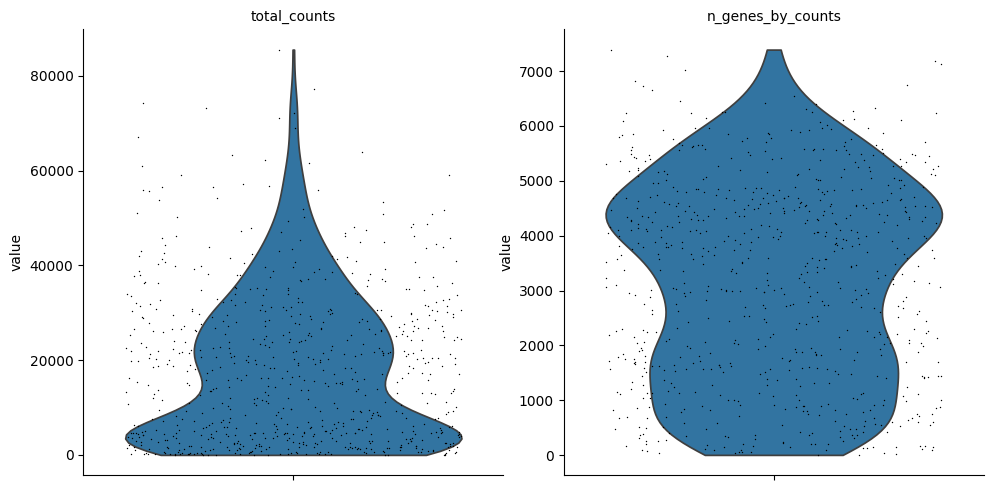

Highly variable genes: 2000


/home/mwc/miniconda3/envs/st/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_27091/3346428174.py:53: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added="cluster")


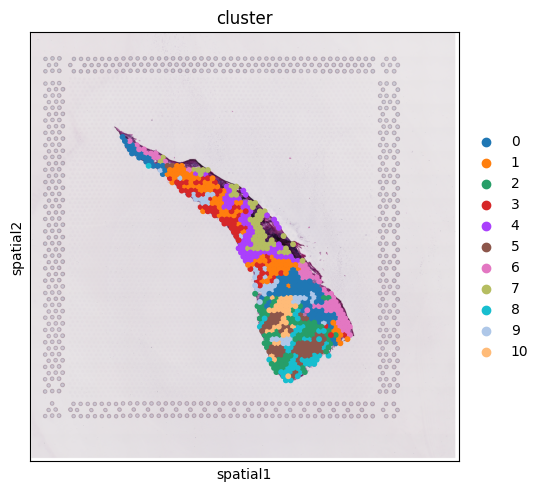

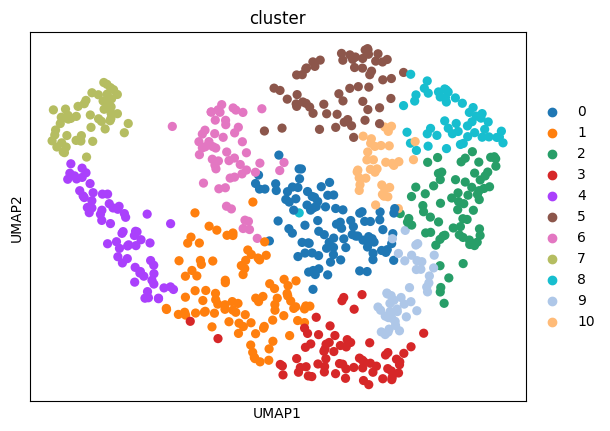

In [4]:
count_df = pd.read_csv("count.csv", index_col=0)
coord_df = pd.read_csv("coord.csv", index_col=0)

adata = ad.AnnData(
    X = count_df.values,     
    obs = pd.DataFrame(index = count_df.index),  
    var = pd.DataFrame(index = count_df.columns)     
)

adata.obsm["spatial"] = coord_df.loc[adata.obs.index, ["xaxis", "yaxis"]].values
adata.obs["r"] = coord_df.loc[adata.obs.index, "r"]

image = Image.open("PNG.png")
adata.uns["spatial"] = {
    'custom_library': {
        'images': {
            'hires': np.array(image)
        },
        'scalefactors': {
            'spot_diameter_fullres': 16.5, 
            'tissue_hires_scalef': 1.0,
            'tissue_lowres_scalef': 0.5
        },
        'metadata': {}
    }
}

print(adata)
print(adata.obsm["spatial"][:5, :])
print(adata.obs.head())


adata.obs["total_counts"] = adata.X.sum(axis=1)
adata.obs["n_genes_by_counts"] = (adata.X > 0).sum(axis=1)
adata.var["n_spots_by_counts"] = (adata.X > 0).sum(axis=0).T

sc.pl.violin(adata, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)
sc.pp.filter_cells(adata, min_counts=1000)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=10)

adata.raw = adata.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)
print(f"Highly variable genes: {adata.var['highly_variable'].sum()}")

sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="cluster")
sq.gr.spatial_neighbors(adata)
sq.pl.spatial_scatter(adata, color="cluster", library_id='custom_library', size=1.65)
sc.pl.umap(adata, color="cluster")

#adata.write("visium.h5ad")

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# 先选一个 spot（比如第0个）
i = 0
x, y = adata.obsm["spatial"][i]
r = adata.obs["r"].iloc[i]  # 你的 r 单位一般是 pixel，若是比例需换算

# 也可以用 spot_diameter_fullres 这个来定半径
spot_diameter = adata.uns["spatial"]['custom_library']['scalefactors']['spot_diameter_fullres']

# 这里假设 patch_size = spot_diameter × 放大系数，比如取 1.5倍
patch_size = spot_diameter * 6
# 打开大图
image = Image.open("PNG.png")

# 裁剪 patch
left = x - patch_size/2
upper = y - patch_size/2
right = x + patch_size/2
lower = y + patch_size/2

patch = image.crop((left, upper, right, lower))

# 画出来看看
plt.figure(figsize=(4,4))
plt.imshow(patch)
plt.axis("off")
plt.title(f"Spot {i}: center=({x:.1f},{y:.1f}), size={patch_size:.1f}px")
plt.show()


NameError: name 'adata' is not defined

In [22]:
adata = sc.read_h5ad("./GSE144239/GSM4565823/visium.h5ad")

In [23]:
# img_container = sq.im.ImageContainer("photo.png")
# for scale in [1.0, 2.0]:
#     feature_name = f"features_summary_scale{scale}"
#     sq.im.calculate_image_features(
#         adata,
#         img_container,
#         features="summary",
#         key_added=feature_name,
#         n_jobs=4,
#         scale=scale,
#     )

In [24]:
# adata.obsm["features"] = pd.concat(
#     [adata.obsm[f] for f in adata.obsm.keys() if "features_summary" in f],
#     axis="columns",
# )

# # make sure that we have no duplicated feature names in the combined table
# adata.obsm["features"].columns = ad.utils.make_index_unique(
#     adata.obsm["features"].columns
# )

In [25]:
# # helper function returning a clustering
# def cluster_features(features: pd.DataFrame, like=None) -> pd.Series:
#     """
#     Calculate leiden clustering of features.

#     Specify filter of features using `like`.
#     """
#     # filter features
#     if like is not None:
#         features = features.filter(like=like)
#     # create temporary adata to calculate the clustering
#     adata = ad.AnnData(features)
#     # important - feature values are not scaled, so need to scale them before PCA
#     sc.pp.scale(adata)
#     # calculate leiden clustering
#     sc.pp.pca(adata, n_comps=min(10, features.shape[1] - 1))
#     sc.pp.neighbors(adata)
#     sc.tl.leiden(adata)

#     return adata.obs["leiden"]


# # calculate feature clusters
# adata.obs["features_cluster"] = cluster_features(adata.obsm["features"], like="summary")

# # compare feature and gene clusters
# sq.pl.spatial_scatter(adata, color=["features_cluster", "cluster"])

In [26]:
# import matplotlib.pyplot as plt
# ax = sq.pl.spatial_scatter(
#     adata,
#     color="cluster",
#     size=1.6,
#     legend_loc="right",
#     return_ax=True  # 🚩 关键，拿到 ax 才能后续加 label
# )

# # 遍历加 label
# for i, (x, y) in enumerate(adata.obsm["spatial"]):
#     label = adata.obs["cluster"].iloc[i]
#     plt.text(
#         x, y, str(label),
#         fontsize=5, color="black", ha="center", va="center"
#     )

# plt.show()

100%|██████████| 1000/1000 [00:10<00:00, 92.24/s]


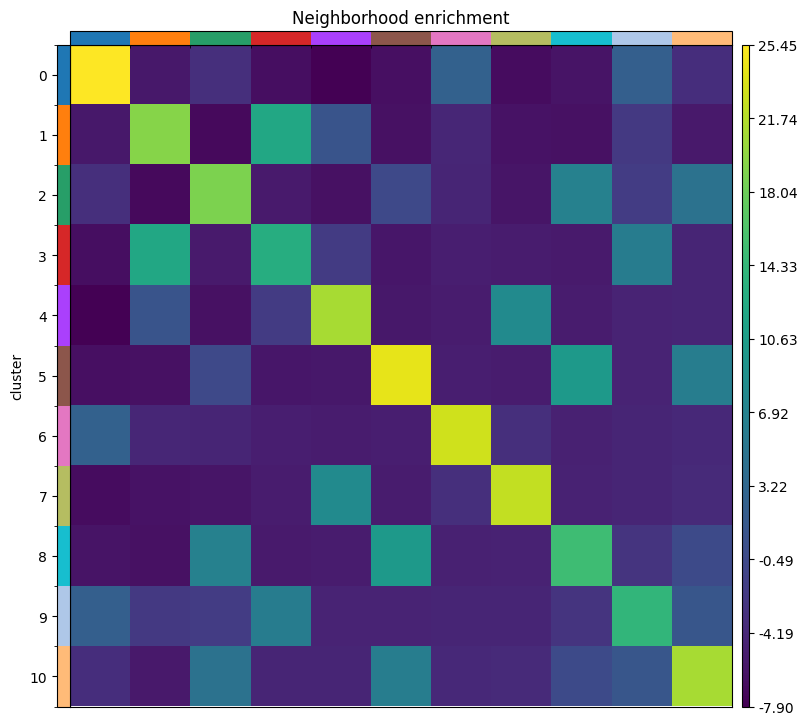

In [27]:
sq.gr.spatial_neighbors(adata)
sq.gr.nhood_enrichment(adata, cluster_key="cluster")
sq.pl.nhood_enrichment(adata, cluster_key="cluster")

In [ ]:
sq.gr.co_occurrence(adata, cluster_key="cluster")

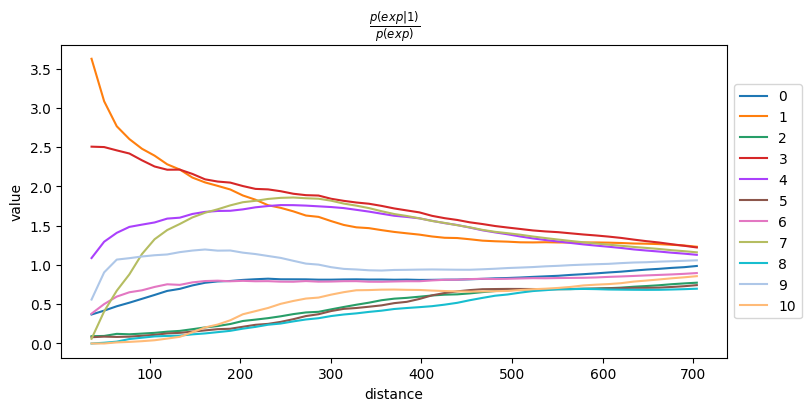

In [34]:
sq.pl.co_occurrence(
    adata,
    cluster_key="cluster",
    clusters="1",
    figsize=(8, 4),
)

In [29]:
adata.var_names 
adata.var

,n_spots_by_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
AL669831.5,19,19,False,0.010106,-0.648781,-2.022689
FAM41C,11,11,False,0.006238,-0.819118,-2.362561
NOC2L,284,284,False,0.258625,-0.137193,-1.001925
KLHL17,41,41,True,0.052545,1.373185,2.011710
PLEKHN1,151,151,False,0.154055,0.745804,0.759906
...,...,...,...,...,...,...
MT-CYB,689,668,False,2.837898,1.782127,0.228372
AC145212.1,17,17,False,0.011404,-0.512055,-1.749883
MAFIP,17,17,False,0.017863,0.464096,0.197817
AL592183.1,15,15,False,0.011610,-0.200459,-1.128159


In [ ]:
sq.gr.ligrec(
    adata,
    n_perms=100,
    cluster_key="cluster",
    use_raw=True
)

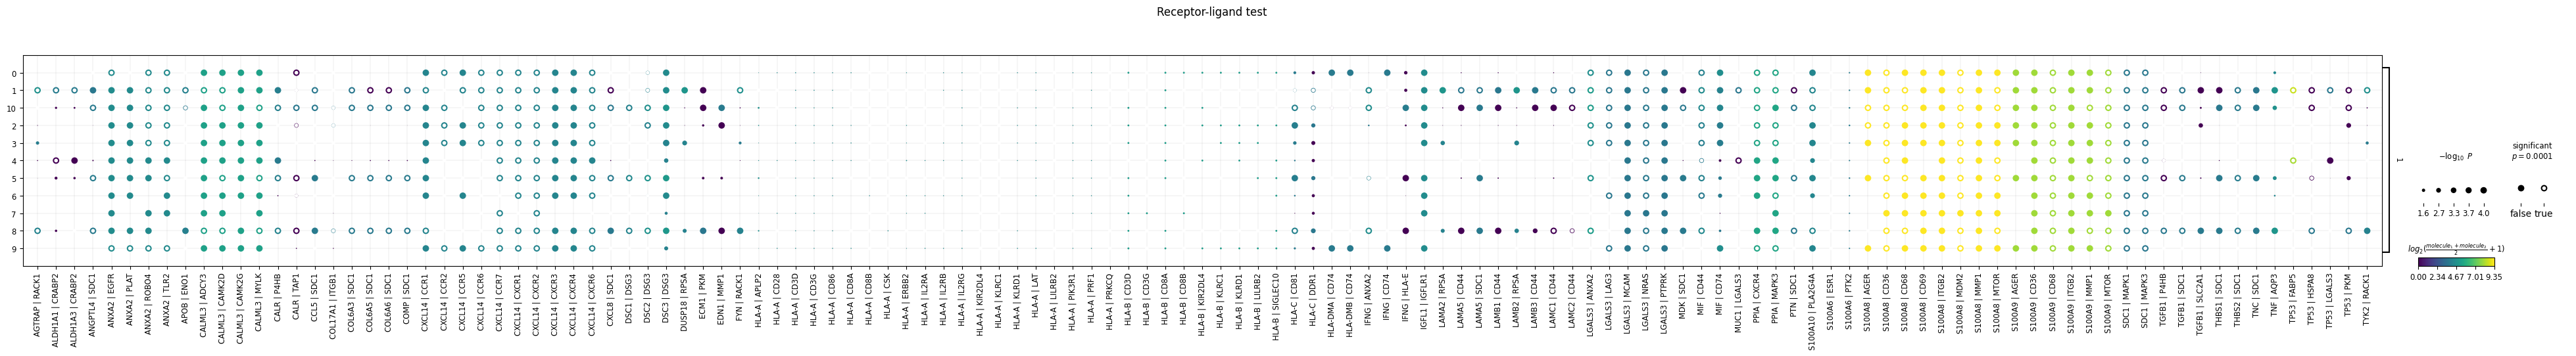

In [37]:
sq.pl.ligrec(
    adata,
    cluster_key="cluster",
    source_groups="1",
    means_range=(12, np.inf),
    alpha=1e-4,
    swap_axes=True,
)

In [39]:
genes = adata[:, adata.var.highly_variable].var_names.values[:1000]
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    genes=genes,
    n_perms=100,
    n_jobs=1,
)

100%|██████████| 100/100 [00:13<00:00,  7.69/s]


In [40]:
adata.uns["moranI"].head(10)

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
LOR,0.814334,0.0,0.000582,0.0,0.009901,0.000962,0.0,0.0,0.020977
FLG,0.804502,0.0,0.000582,0.0,0.009901,0.001053,0.0,0.0,0.020977
HRNR,0.781726,0.0,0.000582,0.0,0.009901,0.001162,0.0,0.0,0.020977
FLG2,0.768182,0.0,0.000582,0.0,0.009901,0.001070,0.0,0.0,0.020977
SLURP1,0.757046,0.0,0.000582,0.0,0.009901,0.001005,0.0,0.0,0.020977
SPRR2A,0.748608,0.0,0.000582,0.0,0.009901,0.001238,0.0,0.0,0.020977
IGFBP3,0.733820,0.0,0.000582,0.0,0.009901,0.001154,0.0,0.0,0.020977
ASPRV1,0.731124,0.0,0.000582,0.0,0.009901,0.000864,0.0,0.0,0.020977
S100A8,0.725780,0.0,0.000582,0.0,0.009901,0.001243,0.0,0.0,0.020977
CDSN,0.698082,0.0,0.000582,0.0,0.009901,0.000659,0.0,0.0,0.020977


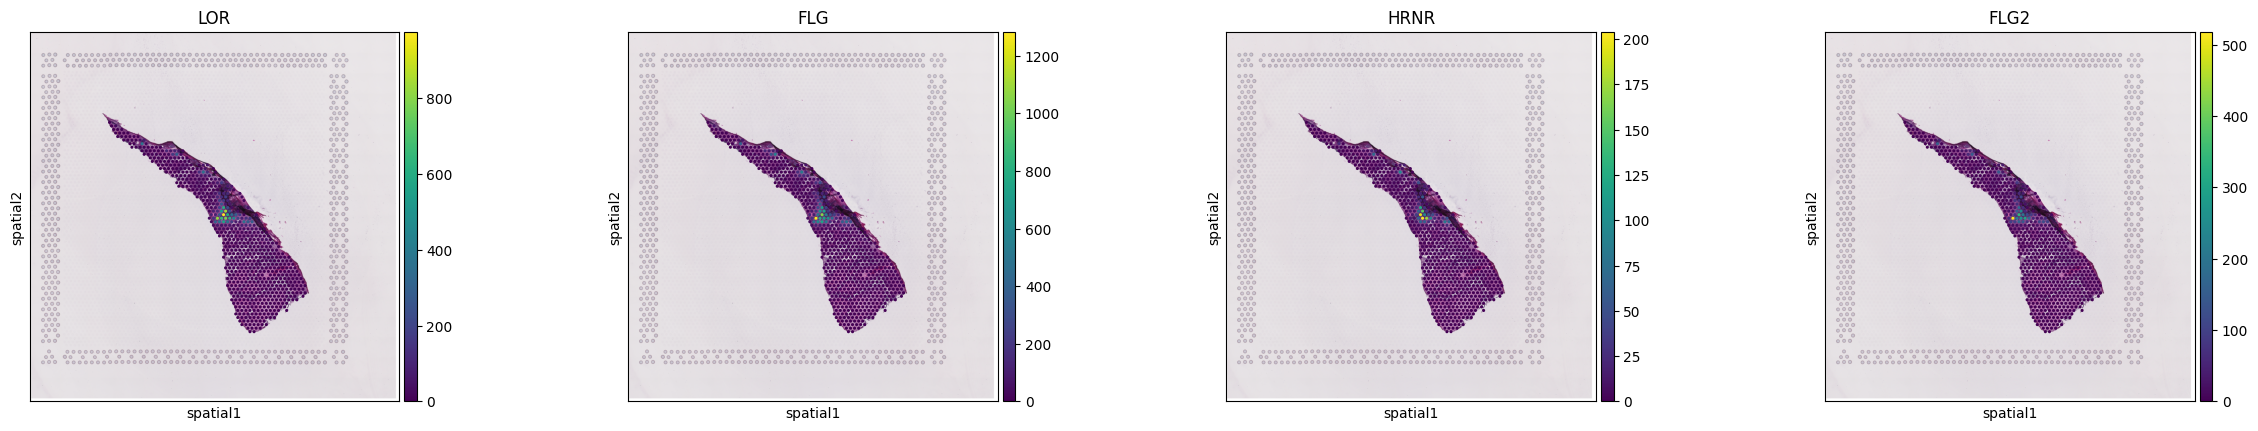

In [42]:
sq.pl.spatial_scatter(adata, color=["LOR", "FLG", "HRNR", "FLG2"])